Метод                          | Итерации   | Вызовы f(x)     | Вызовы grad    
---------------------------------------------------------------------------
Наискорейший спуск             | 9          | 65              | 9              
Сопряж. град. (Флетчер-Ривс)   | 3          | 16              | 4              
Сопряж. град. (Полак-Рибьер)   | 3          | 16              | 4              
Перем. метрика (Бройден)       | 3          | 16              | 5              
Перем. метрика (DFP)           | 3          | 16              | 5              


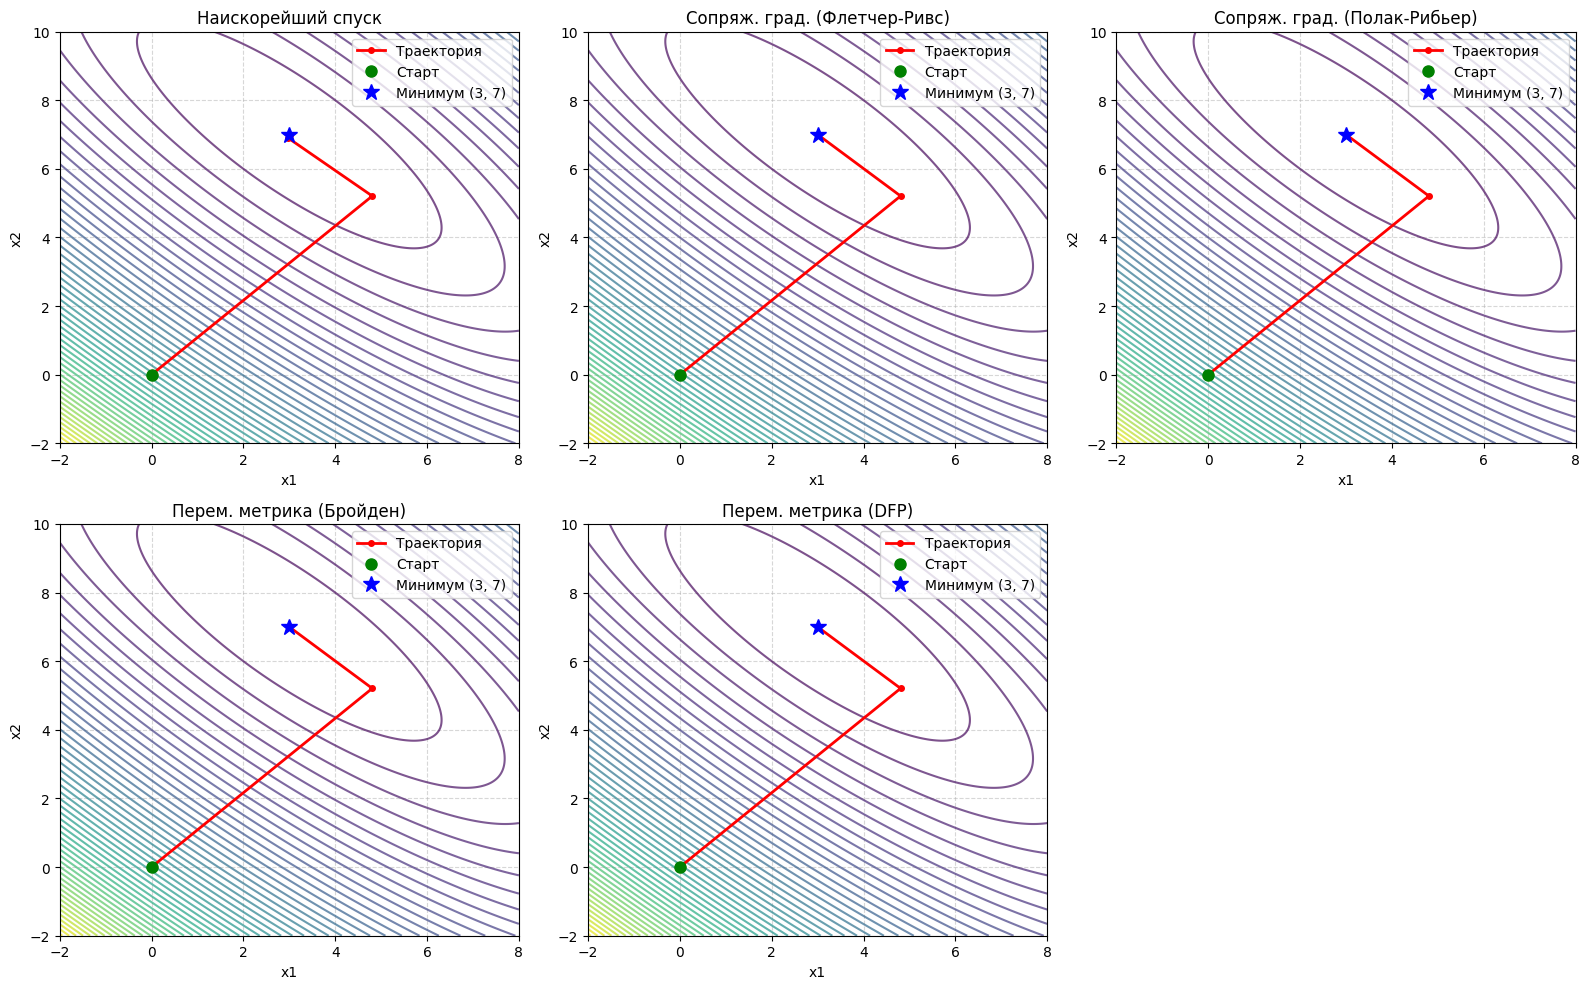


ВЛИЯНИЕ ТОЧНОСТИ ОДНОМЕРНОГО ПОИСКА (Низкая точность: ls_tol = 1e-1)
Метод                          | Итерации   | Вызовы f(x)    
------------------------------------------------------------
Сопряж. град. (Флетчер-Ривс)   | 3          | 16             
Сопряж. град. (Полак-Рибьер)   | 3          | 16             
Перем. метрика (Бройден)       | 3          | 16             
Перем. метрика (DFP)           | 3          | 16             


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- 1. Определение функции и градиента ---

def f_quad(x):
    """Целевая квадратичная функция"""
    x1, x2 = x[0], x[1]
    return 10 * (x1 + x2 - 10)**2 + (x1 - x2 + 4)**2

def grad_quad(x):
    """Градиент квадратичной функции"""
    x1, x2 = x[0], x[1]
    df_dx1 = 20 * (x1 + x2 - 10) + 2 * (x1 - x2 + 4)
    df_dx2 = 20 * (x1 + x2 - 10) - 2 * (x1 - x2 + 4)
    return np.array([df_dx1, df_dx2])

# Класс-обертка для подсчета вызовов функции и градиента
class Objective:
    def __init__(self, f, grad):
        self.f = f
        self.grad = grad
        self.f_calls = 0
        self.g_calls = 0

    def evaluate(self, x):
        self.f_calls += 1
        return self.f(x)

    def evaluate_grad(self, x):
        self.g_calls += 1
        return self.grad(x)

    def reset_counters(self):
        self.f_calls = 0
        self.g_calls = 0

# --- 2. Одномерный поиск ---

def line_search(obj, x, d, tol=1e-5):
    """Минимизация по направлению (поиск лямбда)"""
    def phi(lam):
        return obj.evaluate(x + lam * d)
    
    # Метод brent ищет минимум без обязательного задания жестких границ, 
    # xtol управляет точностью поиска
    res = minimize_scalar(phi, method='brent', options={'xtol': tol})
    return res.x

# --- 3. Методы оптимизации ---

def steepest_descent(obj, x0, tol=1e-5, ls_tol=1e-5, max_iter=1000):
    """Алгоритм наискорейшего спуска"""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    
    for k in range(max_iter):
        g = obj.evaluate_grad(x)
        g_norm = np.linalg.norm(g)
        
        if g_norm < tol:
            break
            
        # Направление спуска с нормировкой (как в лекции)
        S = -g / g_norm
        
        lam = line_search(obj, x, S, tol=ls_tol)
        x = x + lam * S
        history.append(x.copy())
        
    return x, history, k+1

def conjugate_gradient(obj, x0, method='FR', tol=1e-5, ls_tol=1e-5, max_iter=1000):
    """Методы сопряженных градиентов (Флетчера-Ривса или Полака-Рибьера)"""
    x = np.array(x0, dtype=float)
    history =[x.copy()]
    n = len(x)
    
    g_prev = obj.evaluate_grad(x)
    S = -g_prev
    
    for k in range(max_iter):
        g = obj.evaluate_grad(x)
        
        if np.linalg.norm(g) < tol:
            break
            
        # Рестарт каждые n шагов
        if k % n == 0:
            S = -g
        else:
            if method == 'FR':
                omega = np.dot(g, g) / (np.dot(g_prev, g_prev) + 1e-16)
            elif method == 'PR':
                omega = np.dot(g, (g - g_prev)) / (np.dot(g_prev, g_prev) + 1e-16)
            
            S = -g + omega * S
            
        lam = line_search(obj, x, S, tol=ls_tol)
        x_new = x + lam * S
        
        history.append(x_new.copy())
        x = x_new
        g_prev = g.copy()
        
    return x, history, k+1

def variable_metric(obj, x0, method='DFP', tol=1e-5, ls_tol=1e-5, max_iter=1000):
    """Методы переменной метрики (Бройдена или DFP)"""
    x = np.array(x0, dtype=float)
    n = len(x)
    H = np.eye(n) # Начальная матрица (Единичная)
    history =[x.copy()]
    
    for k in range(max_iter):
        g = obj.evaluate_grad(x)
        
        if np.linalg.norm(g) < tol:
            break
            
        S = -np.dot(H, g)
        
        lam = line_search(obj, x, S, tol=ls_tol)
        x_new = x + lam * S
        
        g_new = obj.evaluate_grad(x_new)
        dx = x_new - x
        dg = g_new - g
        
        # Обновление матрицы
        if method == 'Broyden':
            # Формула Бройдена (SR1) из методички
            v = dx - np.dot(H, dg)
            denom = np.dot(v, dg)
            if abs(denom) > 1e-12: # Защита от деления на 0
                H = H + np.outer(v, v) / denom
        elif method == 'DFP':
            # Формула Дэвидона-Флетчера-Пауэлла
            term1 = np.outer(dx, dx) / (np.dot(dx, dg) + 1e-16)
            Hdg = np.dot(H, dg)
            term2 = np.outer(Hdg, Hdg) / (np.dot(dg, Hdg) + 1e-16)
            H = H + term1 - term2
            
        x = x_new
        history.append(x.copy())
        
    return x, history, k+1

# --- 4. Визуализация и Эксперименты ---

def plot_trajectories(histories, titles, func, minimum):
    """Отрисовка линий уровня и траекторий спуска"""
    x1 = np.linspace(-2, 8, 400)
    x2 = np.linspace(-2, 10, 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = func([X1, X2])

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (history, title) in enumerate(zip(histories, titles)):
        ax = axes[i]
        hist_arr = np.array(history)
        
        ax.contour(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
        ax.plot(hist_arr[:, 0], hist_arr[:, 1], 'r.-', linewidth=2, markersize=8, label='Траектория')
        ax.plot(hist_arr[0, 0], hist_arr[0, 1], 'go', markersize=8, label='Старт')
        ax.plot(minimum[0], minimum[1], 'b*', markersize=12, label='Минимум (3, 7)')
        
        ax.set_title(title)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    # Пустой 6-й график удаляем
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

def run_task_1_and_2():
    x0 = [0.0, 0.0]
    minimum_quad =[3.0, 7.0]
    obj = Objective(f_quad, grad_quad)
    
    methods =[
        ("Наискорейший спуск", lambda: steepest_descent(obj, x0)),
        ("Сопряж. град. (Флетчер-Ривс)", lambda: conjugate_gradient(obj, x0, method='FR')),
        ("Сопряж. град. (Полак-Рибьер)", lambda: conjugate_gradient(obj, x0, method='PR')),
        ("Перем. метрика (Бройден)", lambda: variable_metric(obj, x0, method='Broyden')),
        ("Перем. метрика (DFP)", lambda: variable_metric(obj, x0, method='DFP'))
    ]

    histories = []
    titles =[]
    
    print(f"{'Метод':<30} | {'Итерации':<10} | {'Вызовы f(x)':<15} | {'Вызовы grad':<15}")
    print("-" * 75)
    
    for name, method_func in methods:
        obj.reset_counters()
        x_res, hist, iters = method_func()
        histories.append(hist)
        titles.append(name)
        print(f"{name:<30} | {iters:<10} | {obj.f_calls:<15} | {obj.g_calls:<15}")

    plot_trajectories(histories, titles, f_quad, minimum_quad)

    # Эксперимент с плохой точностью одномерного поиска
    print("\n" + "="*75)
    print("ВЛИЯНИЕ ТОЧНОСТИ ОДНОМЕРНОГО ПОИСКА (Низкая точность: ls_tol = 1e-1)")
    print("="*75)
    print(f"{'Метод':<30} | {'Итерации':<10} | {'Вызовы f(x)':<15}")
    print("-" * 60)
    for name, method_func in [m for m in methods if "спуск" not in m[0]]:
        obj.reset_counters()
        # Вызываем методы с плохой точностью поиска
        if "Сопряж" in name:
            meth = 'FR' if 'Флетчер' in name else 'PR'
            x_res, hist, iters = conjugate_gradient(obj, x0, method=meth, ls_tol=1e-1)
        else:
            meth = 'Broyden' if 'Бройден' in name else 'DFP'
            x_res, hist, iters = variable_metric(obj, x0, method=meth, ls_tol=1e-1)
        print(f"{name:<30} | {iters:<10} | {obj.f_calls:<15}")

if __name__ == "__main__":
    run_task_1_and_2()